In [ ]:
import sys
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent directories to path
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'parameters'))
sys.path.insert(0, os.getcwd())

from analysis_utils import (
    load_best_runs,
    load_top_n_runs,
    load_all_runs,
    extract_history,
    add_wall_times,
    plot_2d_histograms,
    plot_convergence_curves,
    plot_time_to_best,
    plot_speedrun_results,
    plot_performance_summary,
    plot_hp_sensitivity,
    print_speedrun_table,
    print_best_hyperparameters,
    save_best_hyperparameters,
    print_ranking_table,
    print_variant_comparison,
    print_variant_comparison_allruns,
    print_hp_sensitivity_table,
    print_offdiag_ranking,
    get_optimizer_colors,
    ALL_OPTIMIZERS,
    ema,
    # Budget-aware statistical methods
    bootstrap_best_run_ci,
    print_topk_comparison,
    print_robustness_table,
    plot_best_of_budget,
)

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

from analysis_utils import (
    plot_diagnostic_curves,
    plot_effective_lr_comparison,
    DIAG_KEYS_METRIC_SCALE,
    DIAG_KEYS_LEARNABLE,
    DIAG_KEYS_CURVATURE,
    DIAG_KEYS_TRAINING,
    DIAG_KEYS_OFFDIAG,
)

# Configuration


In [2]:
# Backend: "wandb" or "local"
BACKEND = "local"

# WandB settings (ignored if BACKEND == "local")
PROJECT = "induced_metric"
ENTITY = "thomas_harvey"  # Change to your WandB entity

# Task settings
TASK_TAG = "mnist_mlp"
ITERATION = 4  # Iteration/batch number to load results from

# Optimizers to analyse
# OPTIMIZERS = ['adam', 'adamw', 'sgd', 'sgd_metric', 'sgd_log_metric', 'muon', 'sgd_rms']
OPTIMIZERS = ALL_OPTIMIZERS  # Uncomment to analyse all optimizers

# Results directory (for local backend)
RESULTS_DIR = os.path.join('..', '..', 'results')

# Metric configuration
SORT_METRIC = "final_max_val_acc"   # WandB summary metric to sort by
SORT_ORDER = "-"                     # "-" descending (higher accuracy = better)
METRIC_KEY = "sweep_metric"          # Local backend sorting key
DIRECTION = "minimize"               # sweep_metric is -accuracy, so lower is better

# Speedrun targets (test accuracy thresholds)
SPEEDRUN_TARGETS = [0.85, 0.90, 0.92, 0.94, 0.96, 0.97, 0.975]
SPEEDRUN_DIRECTION = "above"         # Metric must go ABOVE target
SPEEDRUN_METRIC = "test_acc"

# History metrics to extract
HISTORY_METRICS = ["train_loss", "train_acc", "test_acc", "train_time_seconds"]

# 2D histogram axes
HIST_X = "final_max_acc_epoch"
HIST_Y = "final_max_val_acc"

# Time-to-best keys
BEST_EPOCH_KEY = "final_max_acc_epoch"
BEST_METRIC_KEY = "test_acc"

colors = get_optimizer_colors(OPTIMIZERS)
print(f"Backend: {BACKEND}")
print(f"Task: {TASK_TAG}, Iteration: {ITERATION}")
print(f"Optimizers: {OPTIMIZERS}")

Backend: local
Task: mnist_mlp, Iteration: 4
Optimizers: ['adam', 'adamw', 'sgd', 'muon', 'sgd_metric', 'sgd_log_metric', 'sgd_rms', 'sgd_learn_scalar', 'sgd_learn_scalar_log', 'sgd_learn_diag', 'sgd_learn_diag_log', 'sgd_learn_diag_curv', 'sgd_learn_diag_curv_log', 'sgd_offdiag_0_l', 'sgd_offdiag_0_m', 'sgd_offdiag_0_theta', 'sgd_offdiag_l_0', 'sgd_offdiag_l_l', 'sgd_offdiag_l_m', 'sgd_offdiag_l_theta', 'sgd_offdiag_m_0', 'sgd_offdiag_m_l', 'sgd_offdiag_m_m', 'sgd_offdiag_m_theta', 'sgd_offdiag_theta_0', 'sgd_offdiag_theta_l', 'sgd_offdiag_theta_m', 'sgd_offdiag_theta_theta']


# Load Data


In [3]:
best_runs = load_best_runs(
    backend=BACKEND,
    optimizers=OPTIMIZERS,
    task_tag=TASK_TAG,
    project=PROJECT,
    entity=ENTITY,
    results_dir=RESULTS_DIR,
    metric_key=METRIC_KEY,
    direction=DIRECTION,
    sort_metric=SORT_METRIC,
    sort_order=SORT_ORDER,
    iteration=ITERATION,
)

top_n_runs = load_top_n_runs(
    backend=BACKEND,
    optimizers=OPTIMIZERS,
    n=50,
    task_tag=TASK_TAG,
    project=PROJECT,
    entity=ENTITY,
    results_dir=RESULTS_DIR,
    metric_key=METRIC_KEY,
    direction=DIRECTION,
    sort_metric=SORT_METRIC,
    sort_order=SORT_ORDER,
    iteration=ITERATION,
)

print(f"\nLoaded best runs for {len(best_runs)} optimizers")

Finding best run for adam...


  adam: run_167
Finding best run for adamw...
  adamw: run_970
Finding best run for sgd...


  sgd: run_98
Finding best run for muon...
  muon: run_13
Finding best run for sgd_metric...


  sgd_metric: run_404
Finding best run for sgd_log_metric...
  sgd_log_metric: run_668
Finding best run for sgd_rms...


  sgd_rms: run_391
Finding best run for sgd_learn_scalar...
  sgd_learn_scalar: run_317
Finding best run for sgd_learn_scalar_log...


...

  sgd_offdiag_l_m: 50 runs
Loading top 50 runs for sgd_offdiag_l_theta...
  sgd_offdiag_l_theta: 50 runs
Loading top 50 runs for sgd_offdiag_m_0...


  sgd_offdiag_m_0: 50 runs
Loading top 50 runs for sgd_offdiag_m_l...
  sgd_offdiag_m_l: 50 runs
Loading top 50 runs for sgd_offdiag_m_m...


  sgd_offdiag_m_m: 50 runs
Loading top 50 runs for sgd_offdiag_m_theta...
  sgd_offdiag_m_theta: 50 runs
Loading top 50 runs for sgd_offdiag_theta_0...


  sgd_offdiag_theta_0: 50 runs
Loading top 50 runs for sgd_offdiag_theta_l...
  sgd_offdiag_theta_l: 50 runs
Loading top 50 runs for sgd_offdiag_theta_m...


  sgd_offdiag_theta_m: 50 runs
Loading top 50 runs for sgd_offdiag_theta_theta...
  sgd_offdiag_theta_theta: 50 runs

Loaded best runs for 28 optimizers


# Distribution of Top Runs


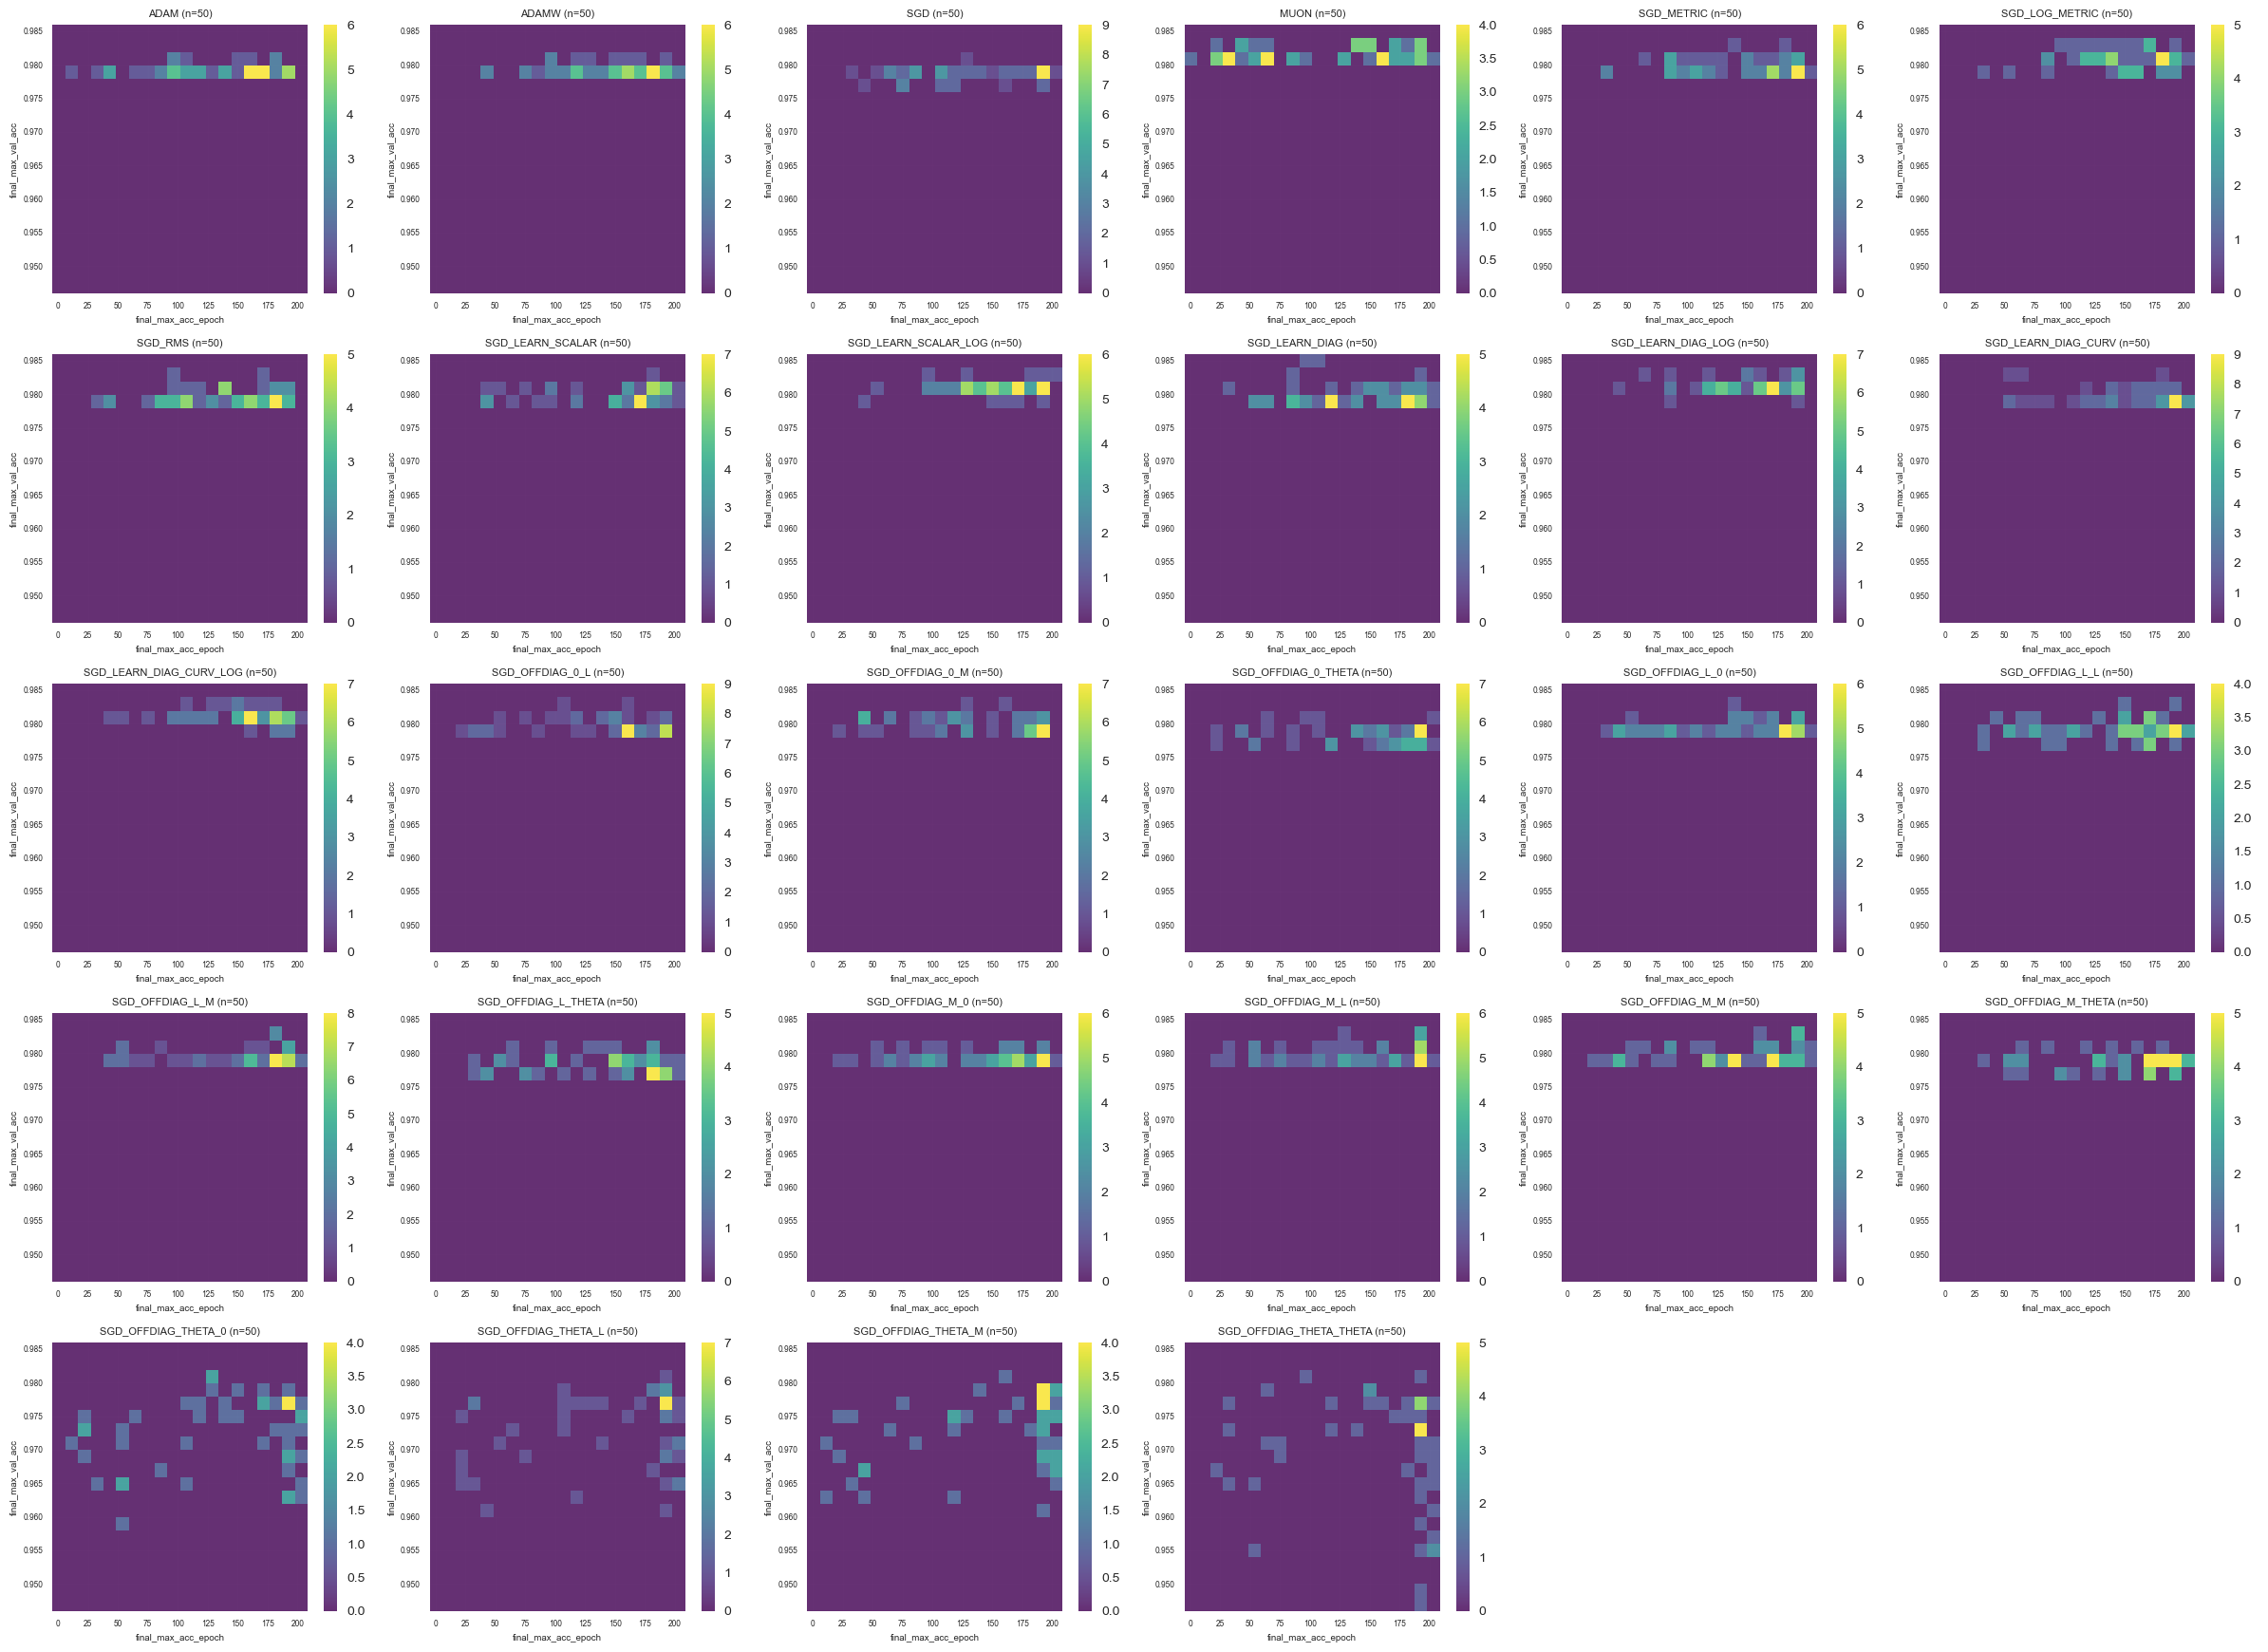

In [4]:
fig = plot_2d_histograms(
    top_n_runs, backend=BACKEND,
    x_metric=HIST_X, y_metric=HIST_Y,
    optimizers=OPTIMIZERS,
)
plt.show()


# Training History


In [5]:
optimizer_data = extract_history(BACKEND, best_runs, HISTORY_METRICS)
add_wall_times(optimizer_data)

print(f"Extracted history for {len(optimizer_data)} optimizers")


Processing adam...
Processing adamw...
Processing sgd...
Processing muon...
Processing sgd_metric...
Processing sgd_log_metric...
Processing sgd_rms...
Processing sgd_learn_scalar...
Processing sgd_learn_scalar_log...
Processing sgd_learn_diag...
Processing sgd_learn_diag_log...
Processing sgd_learn_diag_curv...
Processing sgd_learn_diag_curv_log...
Processing sgd_offdiag_0_l...
Processing sgd_offdiag_0_m...
Processing sgd_offdiag_0_theta...
Processing sgd_offdiag_l_0...
Processing sgd_offdiag_l_l...
Processing sgd_offdiag_l_m...
Processing sgd_offdiag_l_theta...
Processing sgd_offdiag_m_0...
Processing sgd_offdiag_m_l...
Processing sgd_offdiag_m_m...
Processing sgd_offdiag_m_theta...
Processing sgd_offdiag_theta_0...
Processing sgd_offdiag_theta_l...
Processing sgd_offdiag_theta_m...
Processing sgd_offdiag_theta_theta...
Extracted history for 28 optimizers


Time to reach best metric for each optimizer:
  ADAM                :     1.60s at epoch 186 (test_acc: 0.980900)
  ADAMW               :     1.24s at epoch 145 (test_acc: 0.981200)
  SGD                 :     1.07s at epoch 131 (test_acc: 0.980400)
  MUON                :     1.03s at epoch  52 (test_acc: 0.983900)
  SGD_METRIC          :     1.64s at epoch 182 (test_acc: 0.983400)
  SGD_LOG_METRIC      :     0.93s at epoch 103 (test_acc: 0.983700)
  SGD_RMS             :     0.96s at epoch 101 (test_acc: 0.983000)
  SGD_LEARN_SCALAR    :     1.77s at epoch 187 (test_acc: 0.982700)
  SGD_LEARN_SCALAR_LOG:     0.95s at epoch 100 (test_acc: 0.983900)
  SGD_LEARN_DIAG      :     1.07s at epoch 110 (test_acc: 0.984100)
  SGD_LEARN_DIAG_LOG  :     1.60s at epoch 164 (test_acc: 0.983600)
  SGD_LEARN_DIAG_CURV :     0.81s at epoch  68 (test_acc: 0.983900)
  SGD_LEARN_DIAG_CURV_LOG:     2.32s at epoch 186 (test_acc: 0.983800)
  SGD_OFFDIAG_0_L     :     0.99s at epoch 102 (test_acc: 0.982600)

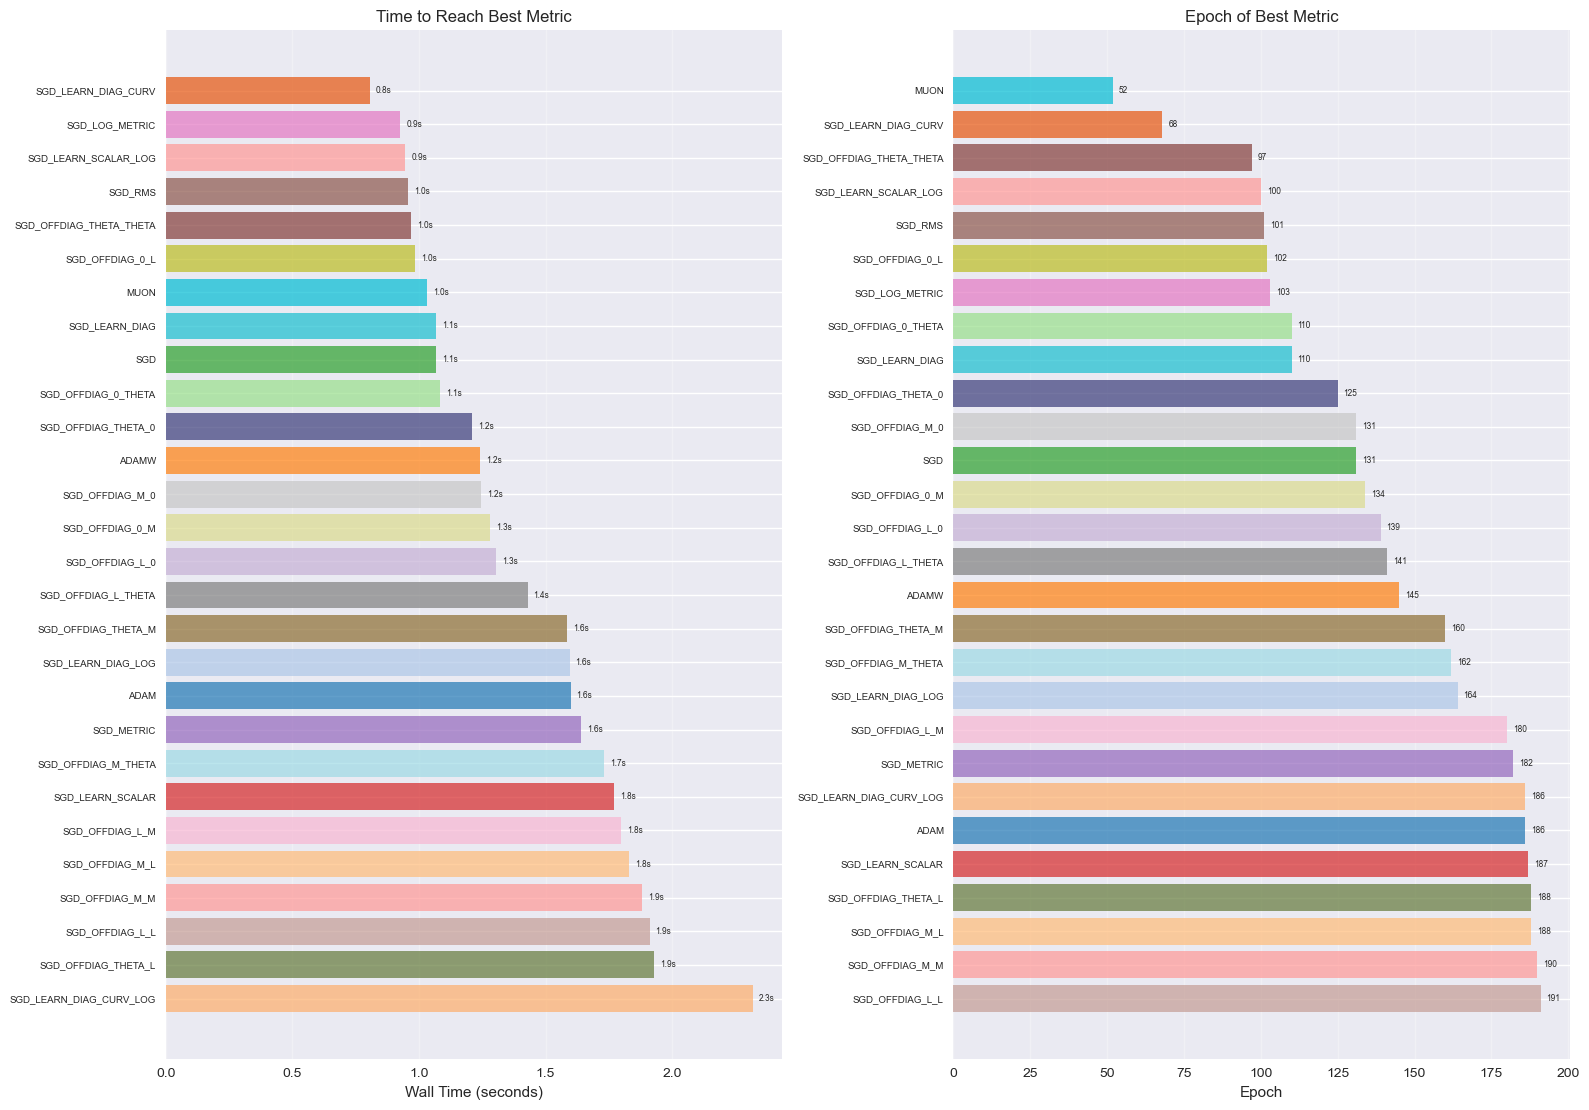

In [6]:
fig = plot_time_to_best(
    best_runs, optimizer_data,
    best_epoch_key=BEST_EPOCH_KEY,
    best_metric_key=BEST_METRIC_KEY,
    colors=colors,
)
plt.show()


# Training Curves


In [ ]:
HIGHLIGHT = ["sgd_learn_diag_curv", "sgd_learn_diag_curv_log"]

# Compute error rate and apply EMA (ema imported from analysis_utils)
optimizer_data_smoothed = {}
for opt, data in optimizer_data.items():
    d = dict(data)
    if "test_acc" in d:
        d["test_error"] = 1.0 - np.asarray(d["test_acc"], dtype=float)
    for key in ["train_loss", "test_error"]:
        if key in d and len(d[key]) > 0:
            d[key] = ema(np.asarray(d[key], dtype=float))
    optimizer_data_smoothed[opt] = d

fig = plot_convergence_curves(
    optimizer_data_smoothed,
    y_keys=["train_loss", "test_error"],
    x_keys=["epoch", "wall_times"],
    mark_best=False,
    colors=colors,
    highlight=HIGHLIGHT,
    y_labels={"train_loss": "Train Loss", "test_error": "Test Error (1 - acc)"},
    x_labels={"epoch": "Epoch", "wall_times": "Wall Time (s)"},
    log_y=True,
)

for ax in fig.axes:
    if ax.get_ylabel() == "Train Loss":
        ax.set_ylim(1e-4, None)

plt.tight_layout()
plt.show()

# Speedrun Analysis


Speedrun Results: Time (seconds) to reach target test accuracy
Optimizer                0.85      0.9       0.92      0.94      0.96      0.97      0.975     
-----------------------------------------------------------------------------------------------
adam                     0.0       0.0       0.0       0.0       0.0       0.0       0.1       
adamw                    0.0       0.0       0.0       0.0       0.0       0.1       0.1       
sgd                      0.0       0.0       0.0       0.0       0.0       0.1       0.1       
muon                     0.0       0.0       0.0       0.1       0.1       0.2       0.2       
sgd_metric               0.0       0.0       0.0       0.0       0.0       0.1       0.1       
sgd_log_metric           0.0       0.0       0.0       0.0       0.0       0.1       0.1       
sgd_rms                  0.0       0.0       0.0       0.0       0.0       0.1       0.1       
sgd_learn_scalar         0.0       0.0       0.0       0.1       0.1     

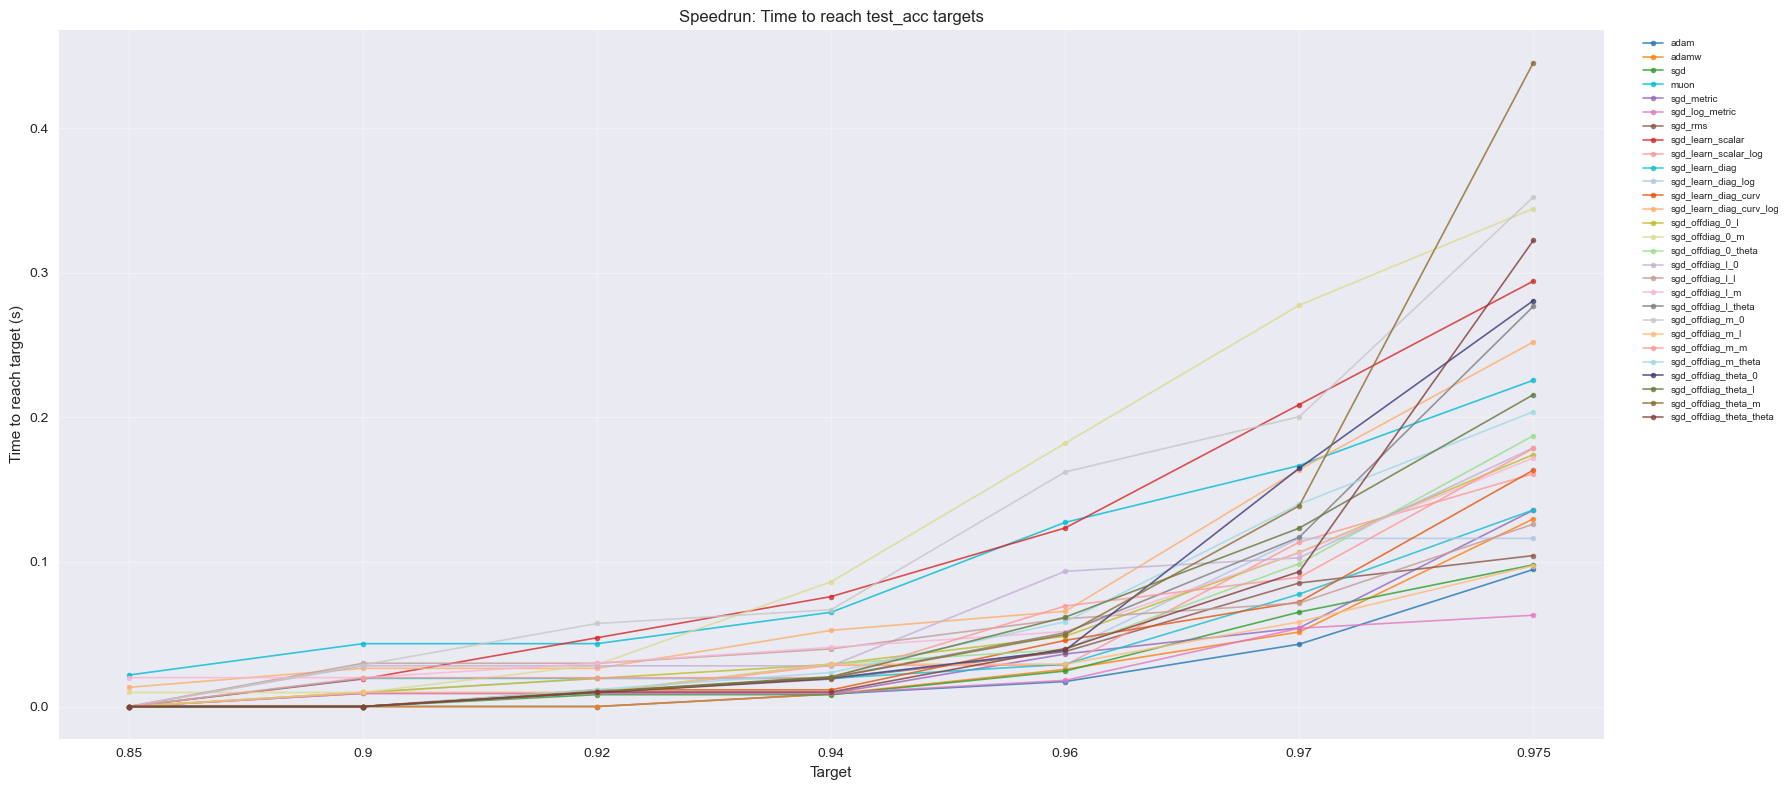

In [8]:
print("Speedrun Results: Time (seconds) to reach target test accuracy")
print("=" * 80)
print_speedrun_table(optimizer_data, SPEEDRUN_TARGETS, SPEEDRUN_METRIC, SPEEDRUN_DIRECTION)

fig = plot_speedrun_results(
    optimizer_data, SPEEDRUN_TARGETS,
    metric_key=SPEEDRUN_METRIC,
    direction=SPEEDRUN_DIRECTION,
    colors=colors,
)
plt.show()


# Performance Summary

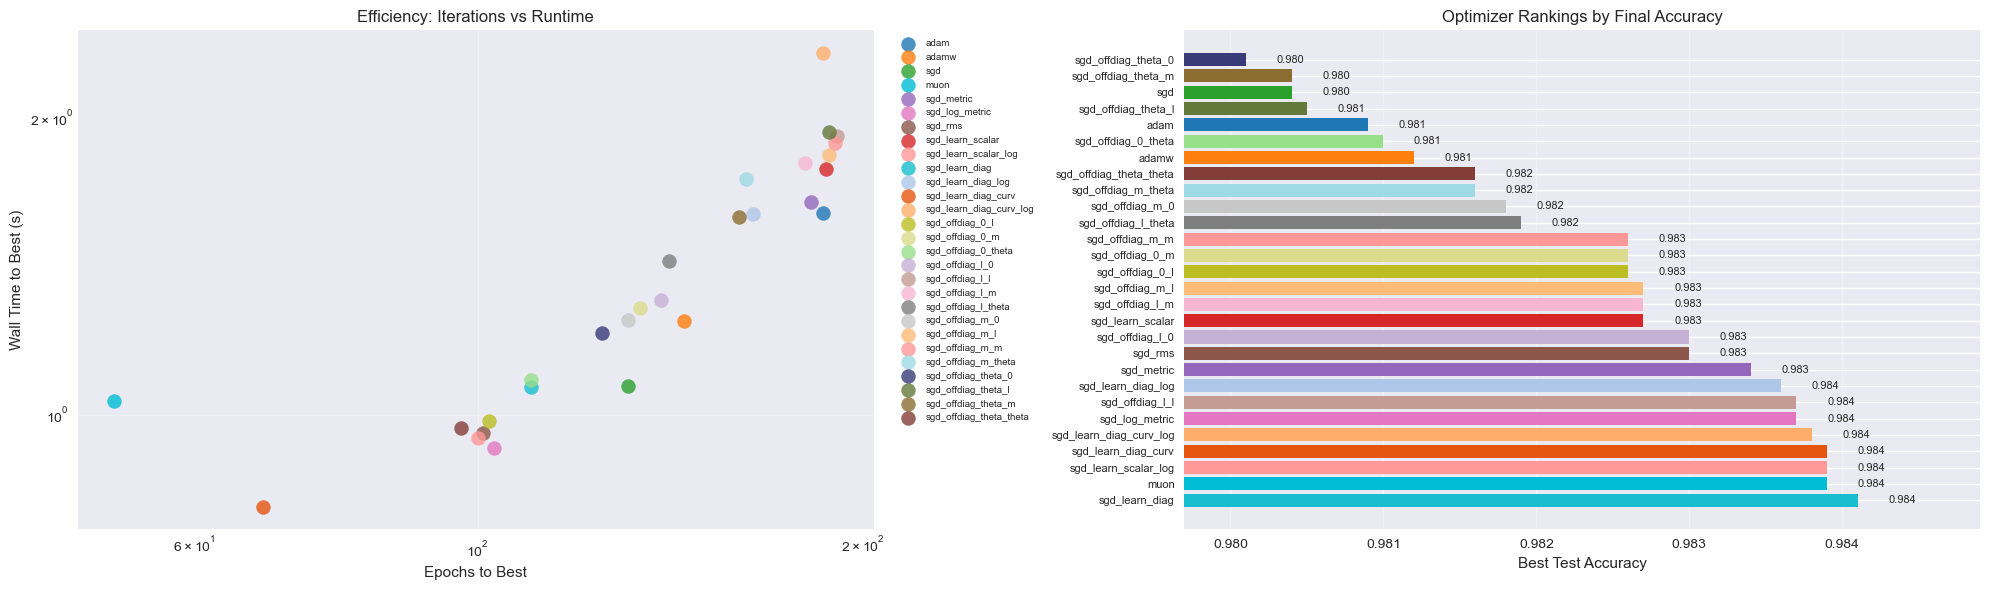

In [9]:
fig = plot_performance_summary(
    best_runs,
    optimizer_data,
    targets=SPEEDRUN_TARGETS,
    metric_key=SPEEDRUN_METRIC,
    direction=SPEEDRUN_DIRECTION,
    epoch_key=BEST_EPOCH_KEY,
    ranking_metric_key="final_max_val_acc",
    colors=colors,
)
plt.show()

# HP Sensitivity

In [10]:
# Load all runs (skip trajectory data to save memory)
all_runs = load_all_runs(
    backend=BACKEND,
    optimizers=OPTIMIZERS,
    task_tag=TASK_TAG,
    results_dir=RESULTS_DIR,
    iteration=ITERATION,
)

Loading all runs for adam...
  adam: 1000 runs
Loading all runs for adamw...
  adamw: 1000 runs
Loading all runs for sgd...
  sgd: 1000 runs
Loading all runs for muon...
  muon: 1000 runs
Loading all runs for sgd_metric...
  sgd_metric: 1000 runs
Loading all runs for sgd_log_metric...
  sgd_log_metric: 1000 runs
Loading all runs for sgd_rms...


  sgd_rms: 1000 runs
Loading all runs for sgd_learn_scalar...
  sgd_learn_scalar: 1000 runs
Loading all runs for sgd_learn_scalar_log...
  sgd_learn_scalar_log: 1000 runs
Loading all runs for sgd_learn_diag...
  sgd_learn_diag: 1000 runs
Loading all runs for sgd_learn_diag_log...
  sgd_learn_diag_log: 1000 runs
Loading all runs for sgd_learn_diag_curv...
  sgd_learn_diag_curv: 1000 runs
Loading all runs for sgd_learn_diag_curv_log...
  sgd_learn_diag_curv_log: 1000 runs
Loading all runs for sgd_offdiag_0_l...


  sgd_offdiag_0_l: 1000 runs
Loading all runs for sgd_offdiag_0_m...
  sgd_offdiag_0_m: 1000 runs
Loading all runs for sgd_offdiag_0_theta...
  sgd_offdiag_0_theta: 1000 runs
Loading all runs for sgd_offdiag_l_0...
  sgd_offdiag_l_0: 1000 runs
Loading all runs for sgd_offdiag_l_l...
  sgd_offdiag_l_l: 1000 runs
Loading all runs for sgd_offdiag_l_m...
  sgd_offdiag_l_m: 1000 runs
Loading all runs for sgd_offdiag_l_theta...
  sgd_offdiag_l_theta: 1000 runs
Loading all runs for sgd_offdiag_m_0...


  sgd_offdiag_m_0: 1000 runs
Loading all runs for sgd_offdiag_m_l...
  sgd_offdiag_m_l: 1000 runs
Loading all runs for sgd_offdiag_m_m...
  sgd_offdiag_m_m: 1000 runs
Loading all runs for sgd_offdiag_m_theta...
  sgd_offdiag_m_theta: 1000 runs
Loading all runs for sgd_offdiag_theta_0...
  sgd_offdiag_theta_0: 1000 runs
Loading all runs for sgd_offdiag_theta_l...
  sgd_offdiag_theta_l: 1000 runs
Loading all runs for sgd_offdiag_theta_m...
  sgd_offdiag_theta_m: 1000 runs
Loading all runs for sgd_offdiag_theta_theta...
  sgd_offdiag_theta_theta: 1000 runs


In [11]:
# for opt in OPTIMIZERS:
#     runs = all_runs.get(opt, [])
#     if not runs:
#         continue
#     fig, axes = plot_hp_sensitivity(
#         runs, opt,
#         convergence_threshold=-0.9,
#         metric_key='sweep_metric',
#         direction='minimize',
#     )
#     plt.show()

# Text-Based Analysis (Paper-Ready Tables)

Rankings, variant comparisons with statistical tests, HP sensitivity tables,
and off-diagonal (a,b) pair comparisons. These complement the plots above
with printable, citable numbers.

In [12]:
# Ranking table (best run per optimizer, sorted by sweep_metric)
print_ranking_table(best_runs, metric_key=METRIC_KEY, direction=DIRECTION,
                    title=f'MNIST MLP (itr {ITERATION}) — Optimizer Ranking')


MNIST MLP (itr 4) — Optimizer Ranking
Rank  Optimizer                     sweep_metric        
--------------------------------------------------------
1     sgd_learn_diag                -0.984100           
2     muon                          -0.983900           
3     sgd_learn_scalar_log          -0.983900           
4     sgd_learn_diag_curv           -0.983900           
5     sgd_learn_diag_curv_log       -0.983800           
6     sgd_log_metric                -0.983700           
7     sgd_offdiag_l_l               -0.983700           
8     sgd_learn_diag_log            -0.983600           
9     sgd_metric                    -0.983400           
10    sgd_rms                       -0.983000           
11    sgd_offdiag_l_0               -0.983000           
12    sgd_learn_scalar              -0.982700           
13    sgd_offdiag_l_m               -0.982700           
14    sgd_offdiag_m_l               -0.982700           
15    sgd_offdiag_0_l               -0.982600    

In [13]:
# Variant comparison (best run): log vs plain, curv vs base, diag vs scalar
print_variant_comparison(best_runs, metric_key=METRIC_KEY, direction=DIRECTION,
                         title=f'MNIST MLP (itr {ITERATION}) — Variant Pairs (Best Run)')


MNIST MLP (itr 4) — Variant Pairs (Best Run)
Comparison                         Base        Variant     Delta       Winner      
-----------------------------------------------------------------------------------
log embedding                      -0.984100   -0.983600   +0.000500   diag        
curvature correction               -0.984100   -0.983900   +0.000200   diag        
curvature correction (log)         -0.983600   -0.983800   -0.000200   log         
log embedding (curv)               -0.983900   -0.983800   +0.000100   curv        
diagonal vs scalar                 -0.982700   -0.984100   -0.001400   diag        
diagonal vs scalar (log)           -0.983900   -0.983600   +0.000300   log         



In [14]:
# Statistical variant comparison (all runs, Mann-Whitney U)
print_variant_comparison_allruns(all_runs, metric_key=METRIC_KEY, direction=DIRECTION,
                                 title=f'MNIST MLP (itr {ITERATION}) — Variant Comparison (All Runs, Mann-Whitney U)')


MNIST MLP (itr 4) — Variant Comparison (All Runs, Mann-Whitney U)
Comparison                    Base med   Var med    n_base  n_var   p-value   Sig?  
------------------------------------------------------------------------------------
log embedding                 -0.865700  -0.846250  1000    1000    0.2443          
curvature correction          -0.865700  -0.780400  1000    1000    0.9635          
curvature correction (log)    -0.846250  -0.578850  1000    1000    0.9892          
log embedding (curv)          -0.780400  -0.578850  1000    1000    0.7489          
diagonal vs scalar            -0.889100  -0.865700  1000    1000    0.9949          
diagonal vs scalar (log)      -0.889600  -0.846250  1000    1000    0.9717          



In [15]:
# HP sensitivity (Spearman correlation with performance) for all optimizers
for opt in OPTIMIZERS:
    runs = all_runs.get(opt, [])
    if len(runs) >= 10:
        print_hp_sensitivity_table(runs, metric_key=METRIC_KEY,
                                   title=f'HP Sensitivity — {opt}')


HP Sensitivity — adam
HP                       Spearman rho   p-value     Sig?  Direction   
----------------------------------------------------------------------
learning_rate            +0.443         0.0000      ***   higher=better
beta1                    +0.044         0.1613            higher=better
beta2                    +0.028         0.3699            higher=better
val_time_seconds         -0.005         0.8818            lower=better


HP Sensitivity — adamw
HP                       Spearman rho   p-value     Sig?  Direction   
----------------------------------------------------------------------
learning_rate            +0.406         0.0000      ***   higher=better
beta2                    +0.101         0.0014      **    higher=better
weight_decay             -0.069         0.0293      *     lower=better
beta1                    +0.030         0.3452            higher=better
val_time_seconds         +0.002         0.9610            higher=better


HP Sensitivity — sgd

/Users/noah-everett/Library/Mobile Documents/com~apple~CloudDocs/Projects/induced-metric-optimiser/repo/analysis/analysis_utils.py:2692: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(vals, perf)


In [16]:
# Off-diagonal (a,b) pair ranking
print_offdiag_ranking(best_runs, metric_key=METRIC_KEY, direction=DIRECTION,
                      title=f'MNIST MLP (itr {ITERATION}) — Off-Diagonal (a,b) Ranking')


MNIST MLP (itr 4) — Off-Diagonal (a,b) Ranking
Rank  a       b       sweep_metric        Name                          
------------------------------------------------------------------------
1     l       l       -0.983700           sgd_offdiag_l_l               
2     l       0       -0.983000           sgd_offdiag_l_0               
3     l       m       -0.982700           sgd_offdiag_l_m               
4     m       l       -0.982700           sgd_offdiag_m_l               
5     0       l       -0.982600           sgd_offdiag_0_l               
6     0       m       -0.982600           sgd_offdiag_0_m               
7     m       m       -0.982600           sgd_offdiag_m_m               
8     l       theta   -0.981900           sgd_offdiag_l_theta           
9     m       0       -0.981800           sgd_offdiag_m_0               
10    m       theta   -0.981600           sgd_offdiag_m_theta           
11    theta   theta   -0.981600           sgd_offdiag_theta_theta       
12 

# Budget-Aware Statistical Analysis

Bootstrap CIs on best-run, top-k comparison, robustness metrics, and
best-of-budget incumbent curves. These control for the maximum order
statistic problem when comparing optimizers with different HP counts.

In [ ]:
# Bootstrap CI on best-run metric
bootstrap_best_run_ci(all_runs, metric_key=METRIC_KEY, direction=DIRECTION,
                      title=f'MNIST MLP (itr {ITERATION}) — Bootstrap 95% CI on Best Run')

# Top-k mean comparison
print_topk_comparison(all_runs, metric_key=METRIC_KEY, direction=DIRECTION,
                      title=f'MNIST MLP (itr {ITERATION}) — Top-k Mean Comparison')

# Robustness table
print_robustness_table(all_runs, metric_key=METRIC_KEY, direction=DIRECTION,
                       title=f'MNIST MLP (itr {ITERATION}) — Robustness Metrics')

In [ ]:
# Best-of-budget incumbent curves
fig = plot_best_of_budget(all_runs, metric_key=METRIC_KEY, direction=DIRECTION,
                          colors=colors,
                          title=f'MNIST MLP (itr {ITERATION}) — Best-of-Budget Incumbent Curve')
plt.show()

# Best Hyperparameters


In [17]:
print_best_hyperparameters(best_runs)

filename = f'best_hyperparameters_MNIST_itr_{ITERATION}.csv'
df = save_best_hyperparameters(best_runs, filename)
df

Hyperparameters for Best Runs

ADAM:
  Run name: run_167
  Config:
    learning_rate: 0.0056581514044715476
    beta1: 0.3064323401234645
    beta2: 0.9626776244394191
    eps: 1e-08
    batch_size: 1024
    architecture: MLP
    val_time_seconds: 0.3001267910003662
  sweep_metric: -0.980900
  final_max_val_acc: 0.980900
----------------------------------------

ADAMW:
  Run name: run_970
  Config:
    learning_rate: 0.0032884482376342094
    beta1: 0.7241714961060847
    beta2: 0.9915277899829948
    eps: 1e-08
    weight_decay: 1.2654063842163958e-05
    batch_size: 1024
    architecture: MLP
    val_time_seconds: 0.29261255264282227
  sweep_metric: -0.981200
  final_max_val_acc: 0.981200
----------------------------------------

SGD:
  Run name: run_98
  Config:
    learning_rate: 0.12069513145865542
    momentum: 0.8881391573530513
    batch_size: 1024
    architecture: MLP
    val_time_seconds: 0.30144667625427246
  sweep_metric: -0.980400
  final_max_val_acc: 0.980400
-----------

,optimizer,run_name,learning_rate,beta1,beta2,eps,batch_size,architecture,val_time_seconds,n_epochs,...,xi,beta_rms,metric_lr,metric_reg,metric_clip,curv_beta,curv_tau,gamma,base_mode,use_momentum_for_update
0,adam,run_167,0.005658,0.306432,0.962678,1.000000e-08,1024,MLP,0.300127,200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,adamw,run_970,0.003288,0.724171,0.991528,1.000000e-08,1024,MLP,0.292613,200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,sgd,run_98,0.120695,NaN,NaN,NaN,1024,MLP,0.301447,200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,muon,run_13,0.006293,NaN,NaN,1.000000e-08,1024,MLP,0.303537,200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,sgd_metric,run_404,5.543206,NaN,NaN,NaN,1024,MLP,0.300662,200,...,5.588430,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,sgd_log_metric,run_668,1.674540,NaN,NaN,NaN,1024,MLP,0.302387,200,...,0.338505,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,sgd_rms,run_391,0.056324,NaN,NaN,1.000000e-08,1024,MLP,0.304239,200,...,0.236943,0.927156,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,sgd_learn_scalar,run_317,0.152522,NaN,NaN,NaN,1024,MLP,0.293585,200,...,1.032076,NaN,0.067699,0.002419,3.454416,NaN,NaN,NaN,NaN,NaN
8,sgd_learn_scalar_log,run_488,0.811870,NaN,NaN,NaN,1024,MLP,0.289471,200,...,0.113863,NaN,0.000423,0.000001,2.087994,NaN,NaN,NaN,NaN,NaN
9,sgd_learn_diag,run_304,7.728445,NaN,NaN,NaN,1024,MLP,0.301852,200,...,6.991042,NaN,0.000503,0.000146,1.616580,NaN,NaN,NaN,NaN,NaN


# Optimizer Diagnostics

Internal state diagnostics (requires `--diagnostics` flag during sweep).
Skips gracefully if no diagnostic data is present.

In [ ]:
# Extract diagnostic metrics from best runs
diag_keys = (
    DIAG_KEYS_METRIC_SCALE + DIAG_KEYS_LEARNABLE +
    DIAG_KEYS_CURVATURE + DIAG_KEYS_TRAINING + DIAG_KEYS_OFFDIAG
)
diag_data = extract_history(BACKEND, best_runs, diag_keys)


In [ ]:
plot_diagnostic_curves(diag_data, DIAG_KEYS_TRAINING,
    title="Training-Level Diagnostics")
plt.show()


In [ ]:
plot_diagnostic_curves(diag_data, DIAG_KEYS_METRIC_SCALE,
    title="Metric Scale (r, v_hat, metric_ema)")
plt.show()


In [ ]:
plot_diagnostic_curves(diag_data, DIAG_KEYS_LEARNABLE,
    title="Learnable Metric Diagnostics")
plt.show()


In [ ]:
plot_effective_lr_comparison(diag_data)
plt.show()


In [ ]:
plot_diagnostic_curves(diag_data, DIAG_KEYS_CURVATURE,
    title="Curvature-Aware Diagnostics")
plt.show()


In [ ]:
plot_diagnostic_curves(diag_data, DIAG_KEYS_OFFDIAG,
    title="Off-Diagonal (Woodbury) Diagnostics")
plt.show()
